## Логистическая регрессия и метод опорных векторов

### Данный ноутбук нужен для отработки линейных методов классификации.
#### Работа будет проводиться на датафрейме [titanic.csv](https://www.kaggle.com/c/titanic)
Будем прогнозировать, выжил ли человек или нет

In [63]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

## Часть 1: Предпроцессинг

In [64]:
df = pd.read_csv('titanic.csv')


Поработаем с null, nan

In [65]:
df  =df.set_index('PassengerId')



print("NaNs: ",df.isna().sum())

NaNs:  Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64


In [66]:
print("nulls: ",df.isnull().sum())

nulls:  Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64


С `Age` поступим следующим образом: заполним пустые значения медианным значением.
`Cabin` сделаем категориальную переменную `Has_Cabin`, где 1 - знаем кабину, 0 - иначе

In [67]:
df['Has_Cabin'] = df['Cabin'].notna().astype(int)

Разделим выборку на тренировочную и тестовую. Уберем лишние столбцы `Cabin`, `Name`, `Ticket` (так как Имя и номер билета у каждого уникальные, кодировкой заниматься смысла нет)

In [68]:
df = df.drop(columns=['Name','Ticket','Cabin'])


Проверим мультиколлениарность между метрическими признаками

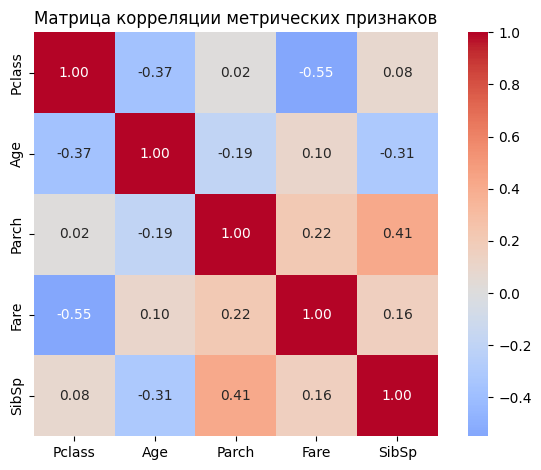

In [69]:
categorial_features = df[['Pclass','Age','Parch','Fare', 'SibSp']]

correlation_matrix = categorial_features.corr()
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            center=0,
            square=True,
            fmt='.2f')
plt.title('Матрица корреляции метрических признаков')
plt.tight_layout()
plt.show()


Сильной попарной корреляции между объектами не наблюдается (pclass не совсем метрический признак, однако его выводить из игры тоже нельзя, так как в датафрейме не просто так задано именно такое отношение порядка, поэтому не включать его нельзя).

При использовании регуляризации точно не будет эксцессов

In [74]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='Survived')
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, train_size=0.7,stratify=y)
avg_age = X_train['Age'].median()
X_train['Age'] = X_train['Age'].fillna(avg_age)
X_test['Age'] = X_test['Age'].fillna(avg_age)

most_common_letter = X_train['Embarked'].dropna().str[0].mode()[0]
X_train['Embarked'] = X_train['Embarked'].fillna(most_common_letter)
X_test['Embarked'] = X_test['Embarked'].fillna(most_common_letter)

X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Has_Cabin
PassengerId,,,,,,,,
749,1,male,19.0,1,0,53.1000,S,1
46,3,male,29.0,0,0,8.0500,S,0
29,3,female,29.0,0,0,7.8792,Q,0
634,1,male,29.0,0,0,0.0000,S,0
404,3,male,28.0,1,0,15.8500,S,0
...,...,...,...,...,...,...,...,...
477,2,male,34.0,1,0,21.0000,S,0
191,2,female,32.0,0,0,13.0000,S,0
737,3,female,48.0,1,3,34.3750,S,0


Закодируем категориальные переменные и воспользуемся стандартизацией признаков

In [75]:
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

ohe = OneHotEncoder(drop='first', handle_unknown='ignore',sparse_output=False)

X_train_cat = ohe.fit_transform(X_train[['Sex', 'Embarked']])
X_test_cat  = ohe.transform(X_test[['Sex', 'Embarked']])

ohe_cols = ohe.get_feature_names_out(['Sex', 'Embarked'])

X_train_cat = pd.DataFrame(X_train_cat, columns=ohe_cols, index=X_train.index)
X_test_cat  = pd.DataFrame(X_test_cat, columns=ohe_cols, index=X_test.index)


mnmxscal = MinMaxScaler()

X_train_num = mnmxscal.fit_transform(X_train[['Age','Parch','Fare','SibSp', 'Pclass']])
X_test_num = mnmxscal.transform(X_test[['Age','Parch','Fare','SibSp', 'Pclass']])

scal_cols = mnmxscal.get_feature_names_out(['Age','Parch','Fare','SibSp', 'Pclass'])

X_train_num = pd.DataFrame(X_train_num, columns=scal_cols, index=X_train.index)
X_test_num  = pd.DataFrame(X_test_num, columns=scal_cols, index=X_test.index)

X_train_final = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_final  = pd.concat([X_test_num, X_test_cat], axis=1)



Предобработали данные: Для категориальных признаков используем `OHE` (`drop = first`, избегаем мультиколлениарности). Для метрических - `MinMaxScaler`. Заметим, что `Pclass` мы тоже нормировали, поскольку SVM чувствителен к нормировке. Такой выбор позволит сохранить вложенное отношение порядка между 1,2,3.

Для тренировочной выборки, по классике, используется `fit_transform`, для тестовой - `transform`

### Итоги части 1:
* Данные очищены от `null`, `NaN`
* В выборке остались только информативные признаки
* Проведена проверка на попарную корреляцию между вещественными признакми
* Выборка разбита на тренировчную и тестовую в соотношении 0,7/0,3 соответсвенно
* Вещественные данные стандартизированы
* Категориальные данные закодированы

## Часть 2: Обучение SVM, LogReg

In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

#подберем значения alpha и C для регуляризации LogReg и SVM соотвественно
parameters_logreg = {'C':[0.1, 0.5, 1, 3, 5, 10]}
parameters_svm = {'kernel':('linear', 'rbf'), 'C':[0.1, 0.5, 1, 3, 5, 10]}

logreg = LogisticRegression(penalty='l2')
svm = SVC()

logreg_clf = GridSearchCV(logreg, n_jobs=5, param_grid=parameters_logreg)
svm_clf = GridSearchCV(svm, n_jobs=5, param_grid=parameters_svm)

logreg_clf.fit(X_train_final, y_train)
svm_clf.fit(X_train_final, y_train)


print("Лучшие гиперпараметры для Логистической регрессии", logreg_clf.best_params_)
print("Лучшие гиперпараметры для svm", svm_clf.best_params_)


Лучшие гиперпараметры для Логистической регрессии {'C': 1}
Лучшие гиперпараметры для svm {'C': 10, 'kernel': 'rbf'}


#### Обучим модели на лучших гиперпараметрах для них

In [77]:
optimal_logreg = LogisticRegression(penalty='l2', C=logreg_clf.best_params_['C'])
optimal_svm = SVC(C = svm_clf.best_params_['C'], kernel=svm_clf.best_params_['kernel'], probability=True)

optimal_logreg.fit(X_train_final, y_train)
optimal_svm.fit(X_train_final, y_train)

SVC(C=10, probability=True)

### Итоги части 2:
* При помощи `GridSearchCV` подобраны гиперпараметры для моделей
* С этими гиперпараметрами обучены `LogisticRegression`, `SVC` на обучающей выборке

### Часть 3: Оценка качества моделей

In [78]:
from sklearn.metrics import roc_auc_score, f1_score


y_pred_logreg = optimal_logreg.predict(X_test_final)
y_pred_svm = optimal_svm.predict(X_test_final)

y_proba_logreg = optimal_logreg.predict_proba(X_test_final)
y_proba_svm = optimal_svm.predict_proba(X_test_final)

f1_for_logreg = f1_score(y_true=y_test, y_pred = y_pred_logreg)
f1_for_svm = f1_score(y_true=y_test, y_pred = y_pred_svm)

roc_auc_score_for_logreg = roc_auc_score(y_true=y_test, y_score = y_proba_logreg[:, 1])
roc_auc_score_for_svm = roc_auc_score(y_true=y_test, y_score = y_proba_svm[:, 1])


print(f"f1 мера для logreg: {f1_for_logreg:.2f}")
print(f"f1 мера для svm: {f1_for_svm:.2f}")

print(f"ROC AUC Score для logreg: {roc_auc_score_for_logreg:.2f}")
print(f"ROC AUC Score мера для svm: {roc_auc_score_for_svm:.2f}")

f1 мера для logreg: 0.73
f1 мера для svm: 0.72
ROC AUC Score для logreg: 0.85
ROC AUC Score мера для svm: 0.87


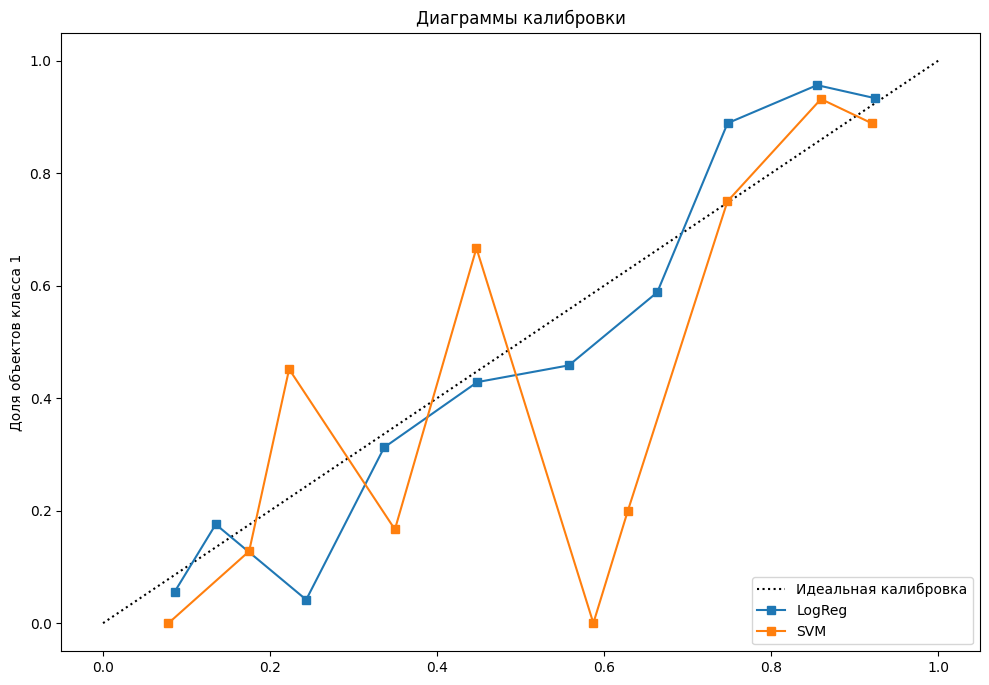

In [81]:
from sklearn.calibration import calibration_curve


plt.figure(figsize=(10, 10))
ax1 = plt.subplot2grid((3, 1), (0, 0), rowspan=2)
ax1.plot([0, 1], [0, 1], "k:", label="Идеальная калибровка")

fraction_of_positives, mean_predicted_value = calibration_curve(
        y_test, y_proba_logreg[:,1], n_bins=10
    )
ax1.plot(mean_predicted_value, fraction_of_positives, "s-", label="%s" % ("LogReg"))

fraction_of_positives, mean_predicted_value = calibration_curve(
        y_test, y_proba_svm[:, 1], n_bins=10
    )
ax1.plot(mean_predicted_value, fraction_of_positives, "s-", label="%s" % ("SVM"))

ax1.set_ylabel("Доля объектов класса 1")
ax1.set_ylim([-0.05, 1.05])
ax1.legend(loc="lower right")
ax1.set_title("Диаграммы калибровки")
plt.tight_layout()
plt.show()

### Выводы:

* Модель логистической регрессии лучше работает с вероятностью (ожидаемо), что видно по калибровочной прямой, так же имеет хорошие показатели `f1 score` и `AUC ROC score`: `0,73` и `0,85` соответсвенно

* SVM уступает в работе с вероятностью, показывая не очень стабильную калибровочную прямую, однако показатели  показатели `f1 score` и `AUC ROC score` лучше: `0,72` и `0,87` соответсвенно.

В рамках конкретно этой задачи мы бы выбирали логрег, которая не очень уступает по основным метрикам, но имеет хороший бонус в виде лучшей предсказывающей способности